In [1]:
from pathlib import Path
from collections import namedtuple
import pprint
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import StandardScaler
import scipy.io
import scipy.linalg

from tqdm.notebook import tqdm

2025-12-28 23:31:23.798864: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-28 23:31:23.838796: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-28 23:31:24.778266: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Math

![](./img/whitening-matrix.jpg)

# Setup

In [2]:
project_root_path = ! git rev-parse --show-toplevel
project_root_path = Path(project_root_path[0])

RNG = np.random.default_rng()

CONFIG = namedtuple('Config', 'project_root_path, data_path, sparsenet_path, dataset_name, dataset_size')(
    project_root_path=project_root_path,
    data_path=project_root_path / 'data',
    sparsenet_path=project_root_path / 'data' / 'sparsenet',
    dataset_name='CIFAR10',
    dataset_size=10_000
)

pprint.pprint(CONFIG._asdict())

{'data_path': PosixPath('/home/misha/dev/mine/neurovision/data'),
 'dataset_name': 'CIFAR10',
 'dataset_size': 10000,
 'project_root_path': PosixPath('/home/misha/dev/mine/neurovision'),
 'sparsenet_path': PosixPath('/home/misha/dev/mine/neurovision/data/sparsenet')}


# Dataset

In [3]:
ImagePatch = namedtuple('ImagePatch', 'patch image_ind i_off j_off')

def extract_image_patch(images, patch_size, image_ind=None, image_stds=None, rng=None):
    blind_area = 4
    trials = 1000
    rng = RNG if rng is None else rng
    image_ind = rng.choice(len(images)) if image_ind is None else image_ind
    image = images[image_ind]

    with_std = not image_stds is None
    
    if with_std:
        image_std_thres = image_stds[image_ind] * .1

    for _ in range(trials):
        i_off = blind_area + rng.choice(image.shape[0] - 2 * blind_area - patch_size)
        j_off = blind_area + rng.choice(image.shape[1] - 2 * blind_area - patch_size)
        patch = image[i_off:i_off + patch_size, j_off:j_off + patch_size]
        
        if with_std:
            patch_std = patch.ravel().std()
    
            if patch_std < image_std_thres:
                continue
        
        break
    else:
        assert False, f'Failed to extract image patch within {trials} trials'
    
    return ImagePatch(patch, image_ind, i_off, j_off)

In [4]:
match CONFIG.dataset_name:
    case 'CIFAR10':
        (IMAGES, y_train), (X_test, y_test) = cifar10.load_data()
        IMAGES = IMAGES[:CONFIG.dataset_size]
        IMAGE_SHAPE = IMAGES.shape[1:3]
        IMAGES = IMAGES[...,1] # get green channel
        IMAGES = IMAGES.reshape(*IMAGES.shape, 1)
    case 'sparsenet':
        mat = scipy.io.loadmat(CONFIG.sparsenet_path / 'IMAGES_RAW.mat')
        raw_images = mat['IMAGESr']
        raw_images = np.moveaxis(raw_images, [2], [0])
        IMAGES = []
        IMAGE_SHAPE = (12, 12)
        
        for i in tqdm(range(CONFIG.dataset_size)):
            patch = extract_image_patch(raw_images, IMAGE_SHAPE[0]).patch
            IMAGES.append(patch.ravel())
        
        IMAGES = np.array(IMAGES)
        IMAGES = IMAGES.reshape(len(IMAGES), *IMAGE_SHAPE, 1)
    case _:
        assert False, f'Unsupported dataset_name={CONFIG.dataset_name}'

print(f'Dataset "{CONFIG.dataset_name}" loaded, {len(IMAGES)} items')

Dataset "CIFAR10" loaded, 10000 items


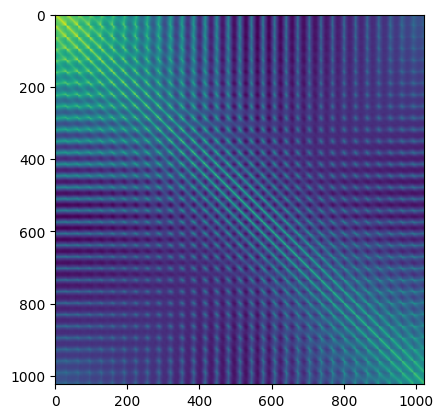

In [5]:
plt.imshow(np.cov(IMAGES.reshape(IMAGES.shape[0], -1), rowvar=False));

# Test Indices

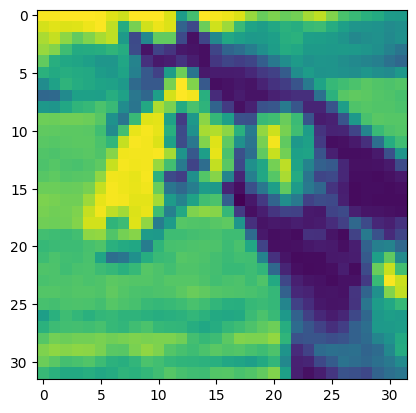

In [80]:
TEST_IMAGE_IND = RNG.choice(len(IMAGES))
filters_count = IMAGES.reshape(len(IMAGES), -1).shape[-1]
TEST_FILTER_INDS = RNG.choice(filters_count, 10, replace=False)
plt.imshow(IMAGES[TEST_IMAGE_IND]);

# Centering

In [118]:
zca_images = IMAGES.astype('float32').copy()
assert zca_images.base is None
print(zca_images.min(), zca_images.max())

zca_images = zca_images.reshape(len(zca_images), -1)
scaler = StandardScaler(with_std=False)
zca_images = scaler.fit_transform(zca_images)
Σ = np.cov(zca_images, rowvar=False)    

0.0 255.0


## Whitened Σ 

In [119]:
np.round(Σ[:8,:8], 2)

array([[5402.04, 5199.69, 5010.7 , 4856.92, 4745.04, 4641.5 , 4545.04,
        4464.34],
       [5199.69, 5254.95, 5114.61, 4916.03, 4787.77, 4670.53, 4567.45,
        4481.9 ],
       [5010.7 , 5114.61, 5218.94, 5074.97, 4899.19, 4762.29, 4648.13,
        4556.26],
       [4856.92, 4916.03, 5074.97, 5182.97, 5053.07, 4865.13, 4728.14,
        4620.63],
       [4745.04, 4787.77, 4899.19, 5053.07, 5156.52, 5016.02, 4825.2 ,
        4692.53],
       [4641.5 , 4670.53, 4762.29, 4865.13, 5016.02, 5117.95, 4977.97,
        4798.29],
       [4545.04, 4567.45, 4648.13, 4728.14, 4825.2 , 4977.97, 5077.54,
        4951.44],
       [4464.34, 4481.9 , 4556.26, 4620.63, 4692.53, 4798.29, 4951.44,
        5069.02]])

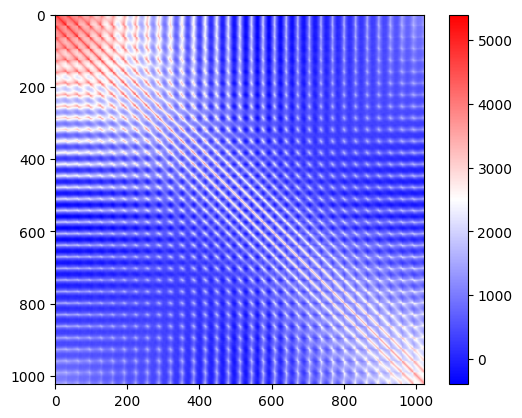

In [120]:
plt.imshow(Σ, cmap='bwr')
plt.colorbar();

## Sample

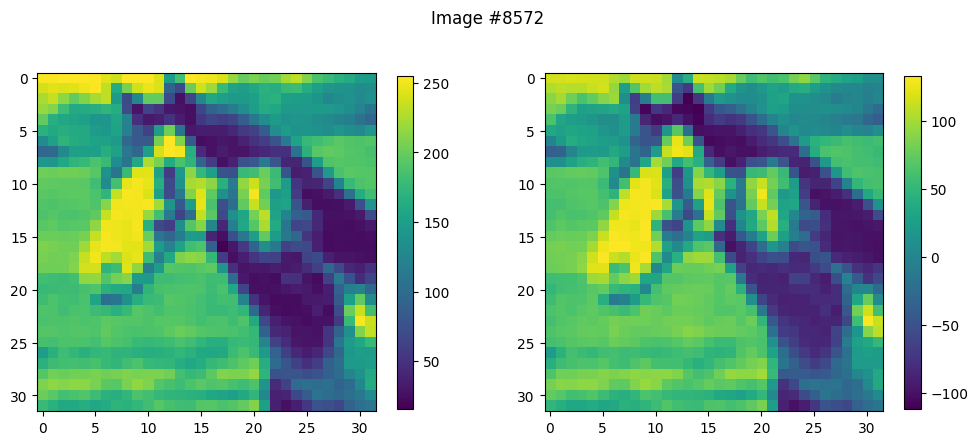

In [121]:
image_ind = TEST_IMAGE_IND # RNG.choice(len(zca_images))

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(12)

fig.suptitle(f'Image #{image_ind}')

im = ax1.imshow(IMAGES[image_ind].reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax1, shrink=0.9)
im = ax2.imshow(zca_images[image_ind].reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax2, shrink=0.9);

# Standardization

In [122]:
zca_images = IMAGES.astype('float32').copy()
assert zca_images.base is None
print(zca_images.min(), zca_images.max())

zca_images = zca_images.reshape(len(zca_images), -1)
scaler = StandardScaler(with_std=True)
zca_images = scaler.fit_transform(zca_images)
Σ = np.cov(zca_images, rowvar=False)    

0.0 255.0


## Whitened Σ 

In [123]:
np.round(Σ[:8,:8], 2)

array([[1.  , 0.98, 0.94, 0.92, 0.9 , 0.88, 0.87, 0.85],
       [0.98, 1.  , 0.98, 0.94, 0.92, 0.9 , 0.88, 0.87],
       [0.94, 0.98, 1.  , 0.98, 0.94, 0.92, 0.9 , 0.89],
       [0.92, 0.94, 0.98, 1.  , 0.98, 0.94, 0.92, 0.9 ],
       [0.9 , 0.92, 0.94, 0.98, 1.  , 0.98, 0.94, 0.92],
       [0.88, 0.9 , 0.92, 0.94, 0.98, 1.  , 0.98, 0.94],
       [0.87, 0.88, 0.9 , 0.92, 0.94, 0.98, 1.  , 0.98],
       [0.85, 0.87, 0.89, 0.9 , 0.92, 0.94, 0.98, 1.  ]])

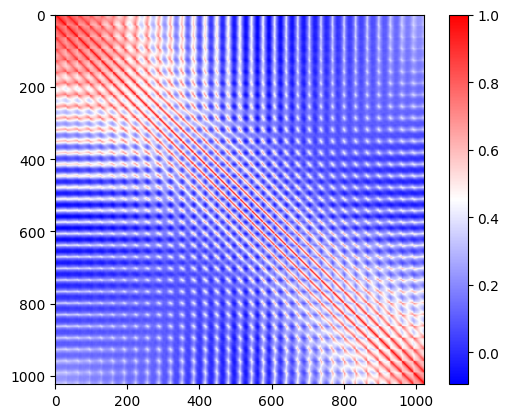

In [124]:
plt.imshow(Σ, cmap='bwr')
plt.colorbar();

## Sample

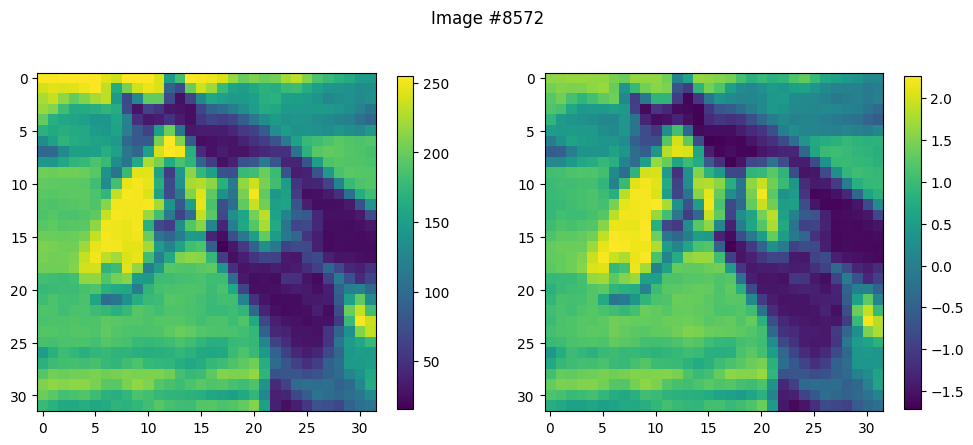

In [125]:
image_ind = TEST_IMAGE_IND # RNG.choice(len(zca_images))

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(12)

fig.suptitle(f'Image #{image_ind}')

im = ax1.imshow(IMAGES[image_ind].reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax1, shrink=0.9)
im = ax2.imshow(zca_images[image_ind].reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax2, shrink=0.9);

# ZCA Whitening via Keras

In [126]:
zca_images = IMAGES.astype('float32').copy()
assert zca_images.base is None
print(zca_images.min(), zca_images.max())

datagen = ImageDataGenerator(featurewise_center=True, zca_whitening=True)
datagen.fit(zca_images)

for i in tqdm(range(len(zca_images))):
    zca_images[i] = datagen.standardize(zca_images[i])

Σ = np.cov(zca_images.reshape(zca_images.shape[0], -1), rowvar=False)    

0.0 255.0


  0%|          | 0/10000 [00:00<?, ?it/s]

## Whitened Σ 

In [127]:
np.round(Σ[:8,:8], 2)

array([[ 1.,  0., -0., -0., -0., -0., -0., -0.],
       [ 0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [-0.,  0.,  1., -0., -0., -0., -0., -0.],
       [-0.,  0., -0.,  1., -0., -0., -0., -0.],
       [-0.,  0., -0., -0.,  1., -0., -0., -0.],
       [-0.,  0., -0., -0., -0.,  1., -0., -0.],
       [-0.,  0., -0., -0., -0., -0.,  1., -0.],
       [-0.,  0., -0., -0., -0., -0., -0.,  1.]])

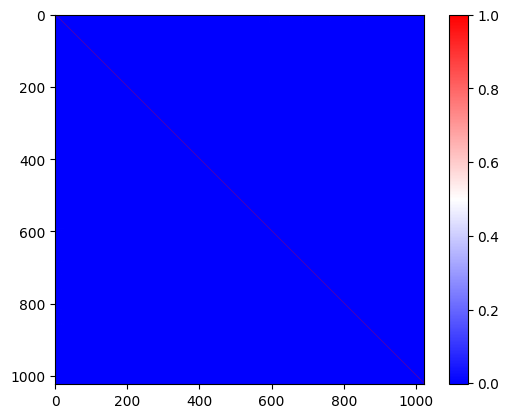

In [128]:
plt.imshow(Σ, cmap='bwr')
plt.colorbar();

## Sample

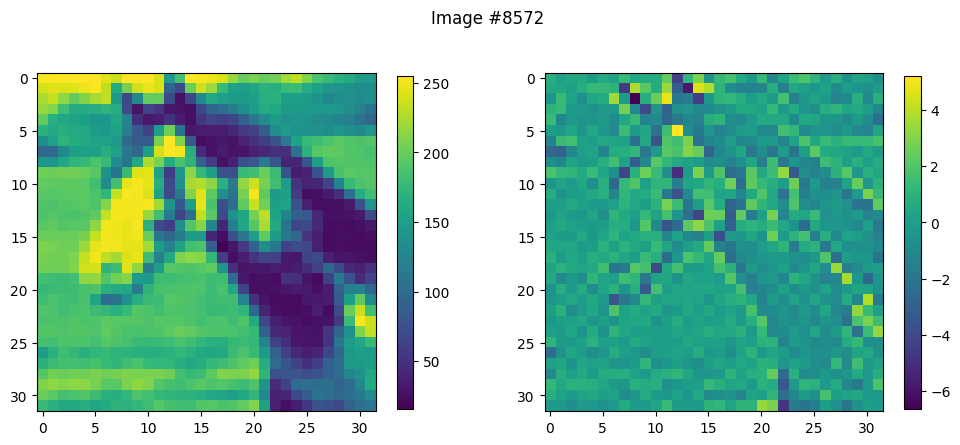

In [129]:
image_ind = TEST_IMAGE_IND # RNG.choice(len(zca_images))

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(12)

fig.suptitle(f'Image #{image_ind}')

im = ax1.imshow(IMAGES[image_ind].reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax1, shrink=0.9)
im = ax2.imshow(zca_images[image_ind].reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax2, shrink=0.9);

# ZCA Whitening via Home-made: clamp [0,1]

In [130]:
zca_images = IMAGES.astype('float32').copy()
assert zca_images.base is None
print(zca_images.min(), zca_images.max())

zca_images = zca_images.reshape(len(zca_images), -1)
mins = zca_images.min(axis=0)
maxs = zca_images.max(axis=0)
zca_images = (zca_images - mins) / (maxs - mins)

zca_images = zca_images - zca_images.mean(axis=0)

Σ = np.cov(zca_images, rowvar=False)
u, s, _ = np.linalg.svd(Σ)
# zca_images = (u @ np.diag(1.0 / np.sqrt(s + 1e-6)) @ u.T @ zca_images.T).T
W = u @ np.diag(1.0 / np.sqrt(s + 1e-6)) @ u.T
W_inv = u @ np.diag(np.sqrt(s + 1e-6)) @ u.T
zca_images = (W @ zca_images.T).T

Σ = np.cov(zca_images, rowvar=False)    

0.0 255.0


In [131]:
# assertion of W's symmetry in a various of ways
assert np.all(np.isclose(W, W.T))
assert np.allclose(W, W.T)
assert scipy.linalg.issymmetric(W, rtol=1e-05, atol=1e-08)

## Whitened Σ 

In [132]:
np.round(Σ[:8,:8], 2)

array([[ 1.,  0., -0.,  0., -0.,  0., -0., -0.],
       [ 0.,  1.,  0., -0.,  0., -0.,  0., -0.],
       [-0.,  0.,  1.,  0., -0.,  0., -0.,  0.],
       [ 0., -0.,  0.,  1.,  0., -0.,  0., -0.],
       [-0.,  0., -0.,  0.,  1.,  0., -0.,  0.],
       [ 0., -0.,  0., -0.,  0.,  1.,  0., -0.],
       [-0.,  0., -0.,  0., -0.,  0.,  1.,  0.],
       [-0., -0.,  0., -0.,  0., -0.,  0.,  1.]])

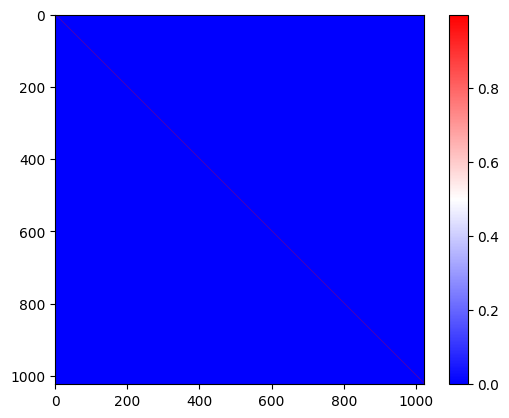

In [133]:
plt.imshow(Σ, cmap='bwr')
plt.colorbar();

## Whitening Filters

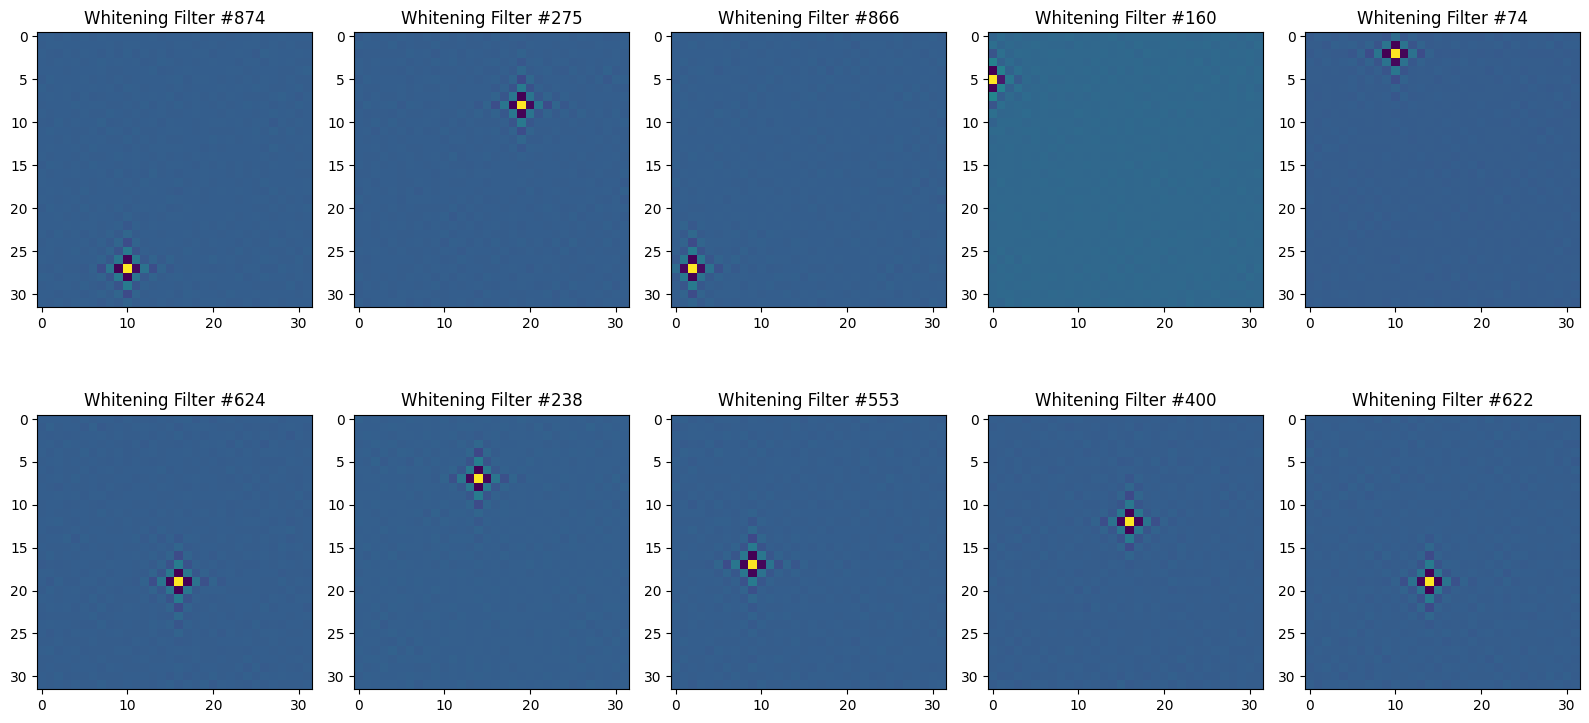

In [134]:
fig, axes = plt.subplots(len(TEST_FILTER_INDS) // 5, 5)
fig.set_figwidth(16)
fig.set_figheight(8)

for ind, ax in zip(TEST_FILTER_INDS, axes.ravel()):
    ax.set_title(f'Whitening Filter #{ind}')
    ax.imshow(W[ind].reshape(IMAGE_SHAPE));

fig.tight_layout()

## Dewhitening Filters

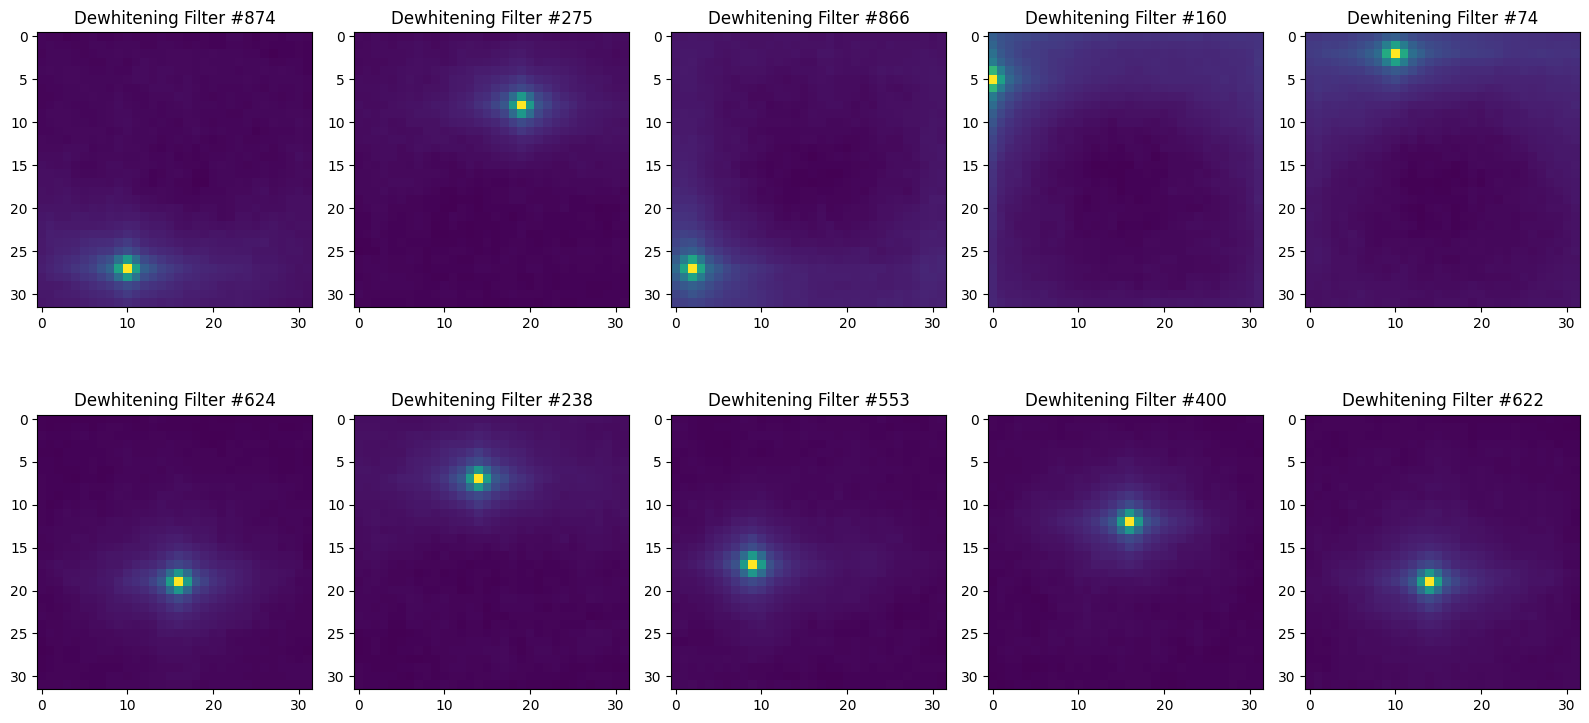

In [135]:
fig, axes = plt.subplots(len(TEST_FILTER_INDS) // 5, 5)
fig.set_figwidth(16)
fig.set_figheight(8)

for ind, ax in zip(TEST_FILTER_INDS, axes.ravel()):
    ax.set_title(f'Dewhitening Filter #{ind}')
    ax.imshow(W_inv[ind].reshape(IMAGE_SHAPE));

fig.tight_layout()

## Sample

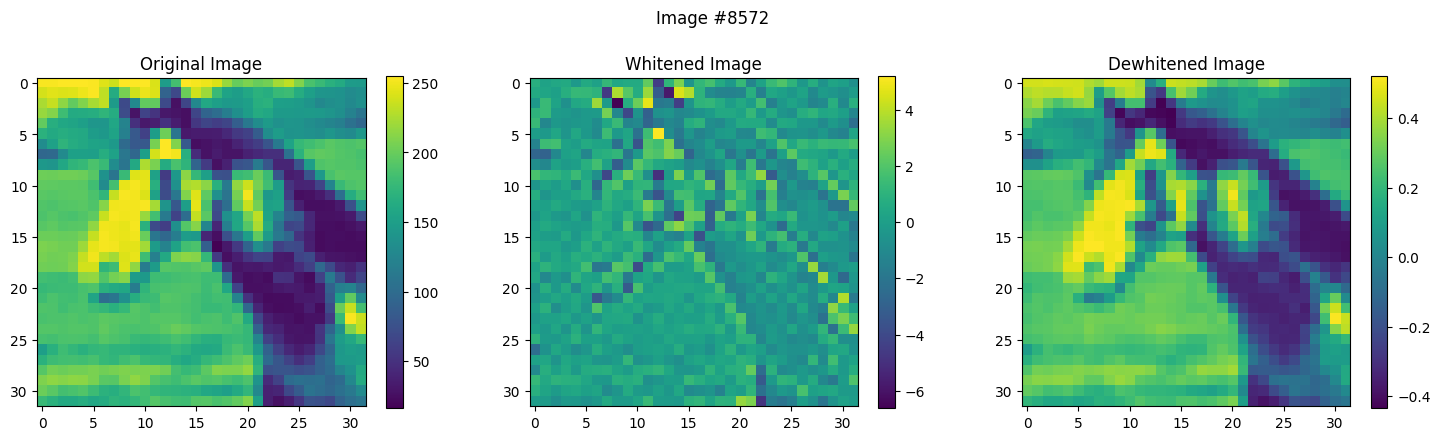

In [136]:
image_ind = TEST_IMAGE_IND # RNG.choice(len(zca_images))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figwidth(18)

fig.suptitle(f'Image #{image_ind}')

ax1.set_title('Original Image')
original_image = IMAGES[image_ind]
im = ax1.imshow(original_image.reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax1, shrink=0.9)

ax2.set_title('Whitened Image')
whitened_image = zca_images[image_ind]
im = ax2.imshow(whitened_image.reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax2, shrink=0.9);

ax3.set_title('Dewhitened Image')
dewhitened_image = W_inv @ whitened_image
im = ax3.imshow(dewhitened_image.reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax3, shrink=0.9);

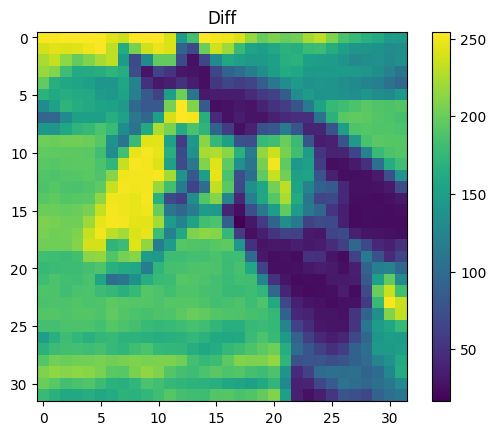

In [137]:
plt.title('Diff')
plt.imshow((original_image.ravel() - dewhitened_image.ravel()).reshape(IMAGE_SHAPE))
plt.colorbar();

# ZCA Whitening via Home-made: no clamp

In [138]:
zca_images = IMAGES.astype('float32').copy()
assert zca_images.base is None
print(zca_images.min(), zca_images.max())

scaler = StandardScaler(with_std=False)
zca_images = zca_images.reshape(len(zca_images), -1)
zca_images = scaler.fit_transform(zca_images)

Σ = np.cov(zca_images, rowvar=False)
u, s, _ = np.linalg.svd(Σ)
# zca_images = (u @ np.diag(1.0 / np.sqrt(s + 1e-6)) @ u.T @ zca_images.T).T
W = u @ np.diag(1.0 / np.sqrt(s + 1e-6)) @ u.T
W_inv = u @ np.diag(np.sqrt(s + 1e-6)) @ u.T
zca_images = (W @ zca_images.T).T

Σ = np.cov(zca_images, rowvar=False)    

0.0 255.0


In [139]:
# assertion of W's symmetry in a various of ways
assert np.all(np.isclose(W, W.T))
assert np.allclose(W, W.T)
assert scipy.linalg.issymmetric(W, rtol=1e-05, atol=1e-08)

## Whitened Σ 

In [140]:
np.round(Σ[:8,:8], 2)

array([[ 1.,  0., -0.,  0., -0.,  0., -0., -0.],
       [ 0.,  1.,  0., -0.,  0., -0.,  0., -0.],
       [-0.,  0.,  1.,  0., -0.,  0., -0.,  0.],
       [ 0., -0.,  0.,  1.,  0., -0.,  0., -0.],
       [-0.,  0., -0.,  0.,  1.,  0., -0.,  0.],
       [ 0., -0.,  0., -0.,  0.,  1.,  0., -0.],
       [-0.,  0., -0.,  0., -0.,  0.,  1.,  0.],
       [-0., -0.,  0., -0.,  0., -0.,  0.,  1.]])

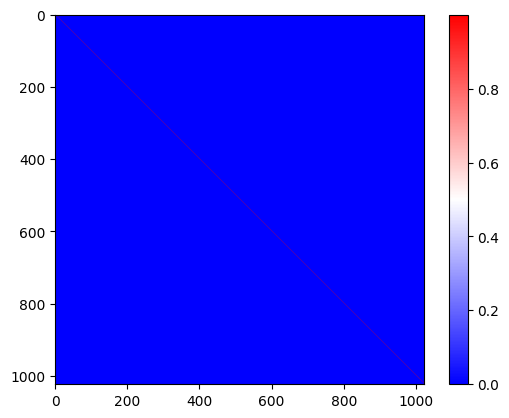

In [141]:
plt.imshow(Σ, cmap='bwr')
plt.colorbar();

## Whitening Filters

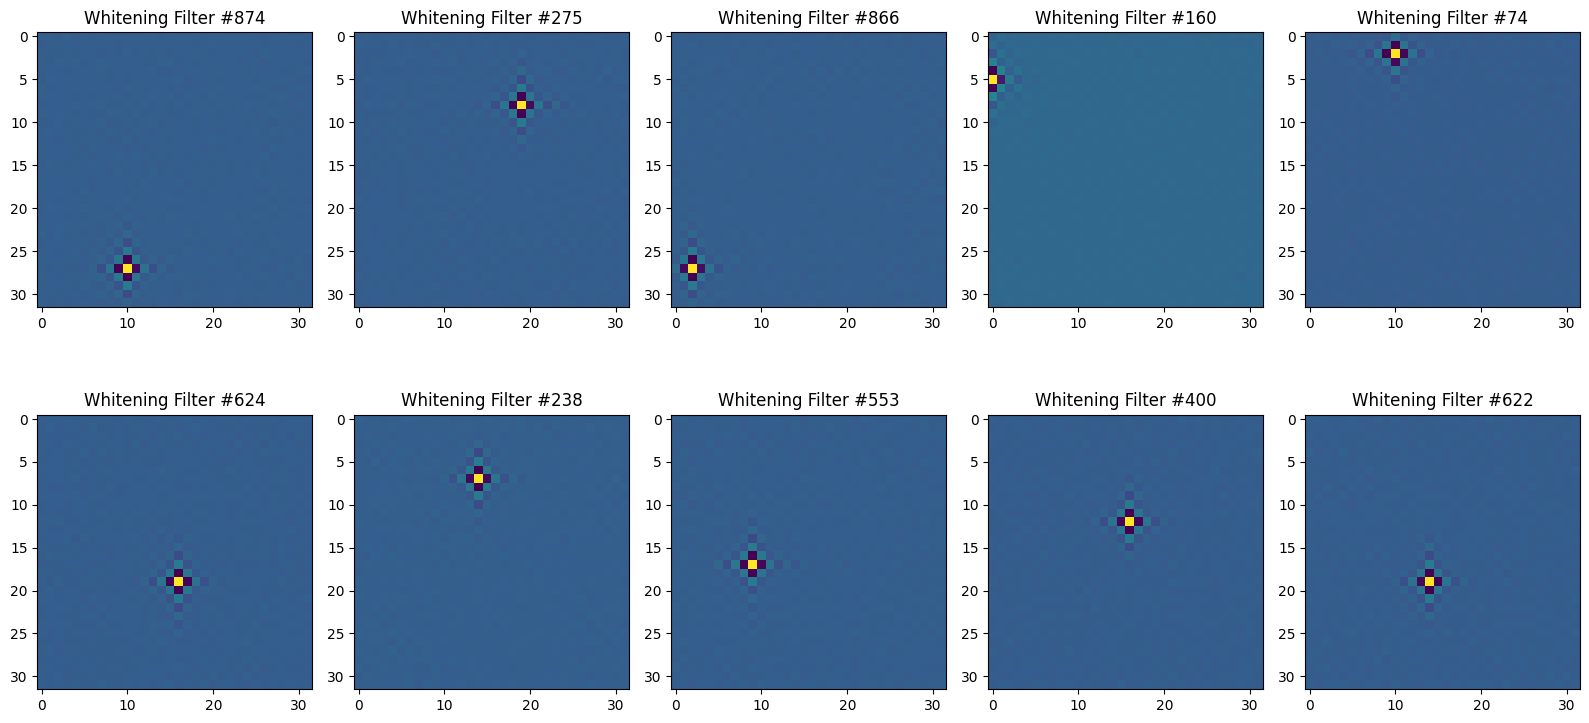

In [142]:
fig, axes = plt.subplots(len(TEST_FILTER_INDS) // 5, 5)
fig.set_figwidth(16)
fig.set_figheight(8)

for ind, ax in zip(TEST_FILTER_INDS, axes.ravel()):
    ax.set_title(f'Whitening Filter #{ind}')
    ax.imshow(W[ind].reshape(IMAGE_SHAPE));

fig.tight_layout()

## Dewhitening Filters

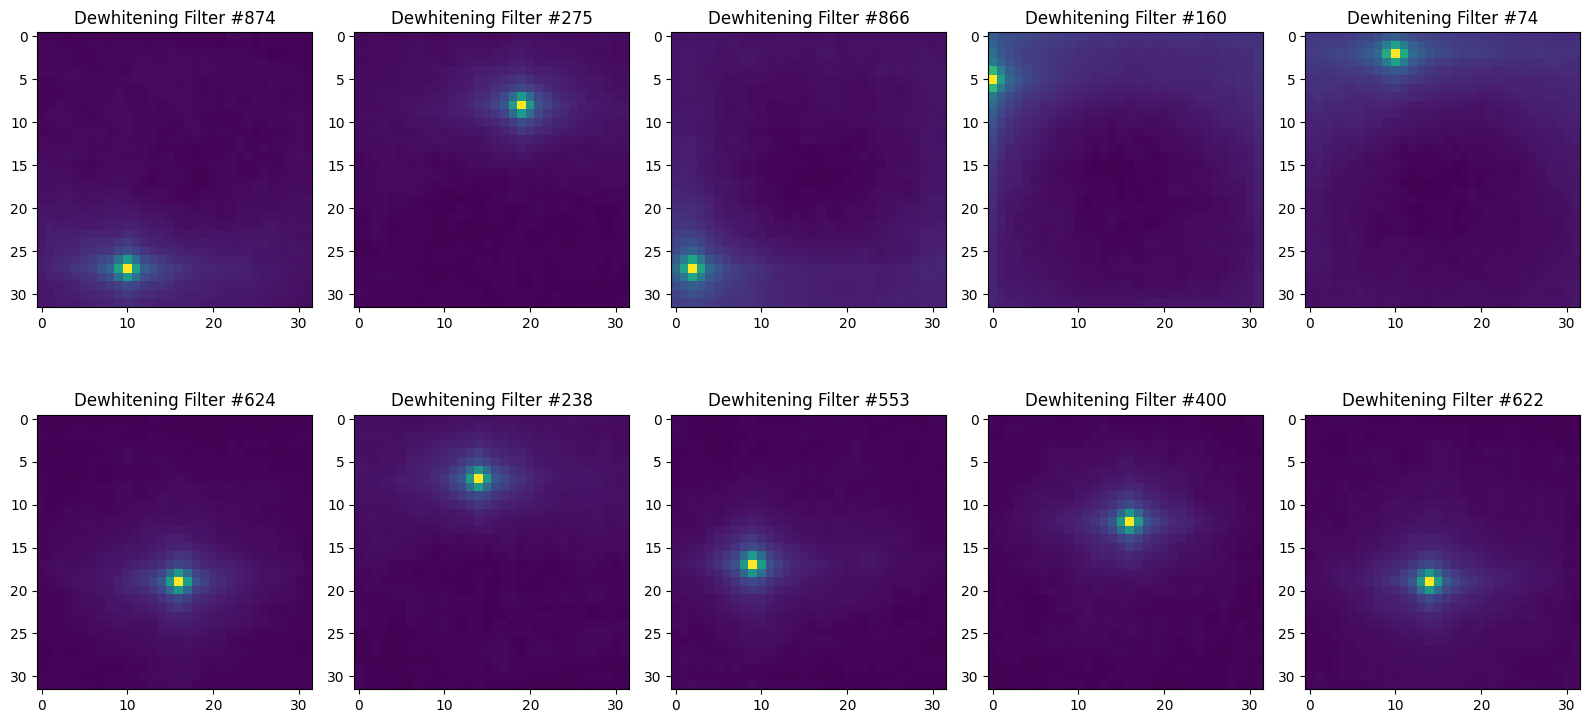

In [143]:
# W_inv = np.linalg.inv(W)

fig, axes = plt.subplots(len(TEST_FILTER_INDS) // 5, 5)
fig.set_figwidth(16)
fig.set_figheight(8)

for ind, ax in zip(TEST_FILTER_INDS, axes.ravel()):
    ax.set_title(f'Dewhitening Filter #{ind}')
    ax.imshow(W_inv[ind].reshape(IMAGE_SHAPE));

fig.tight_layout()

## Sample

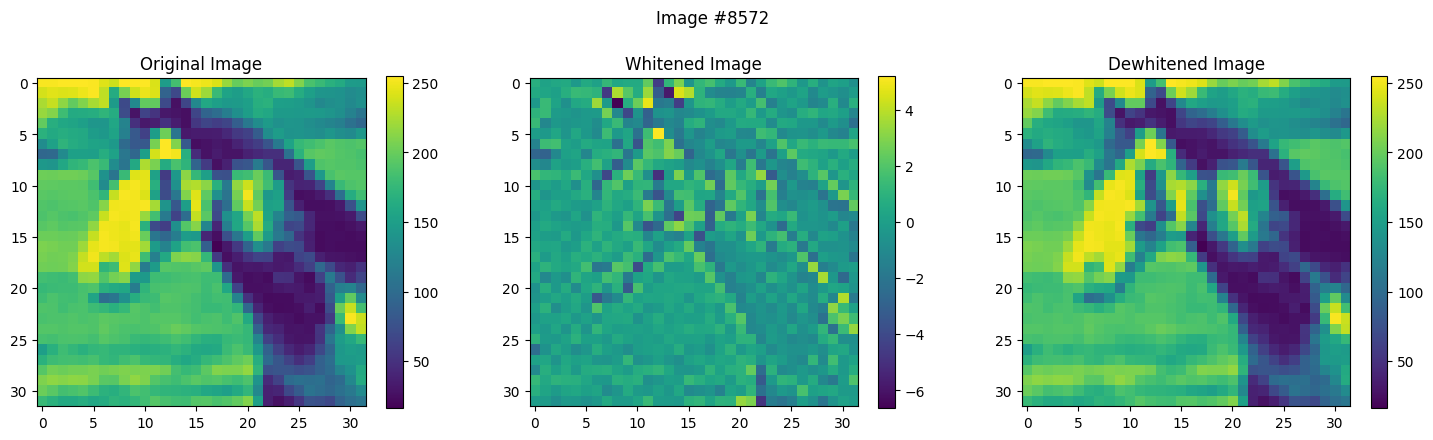

In [144]:
image_ind = TEST_IMAGE_IND # RNG.choice(len(zca_images))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figwidth(18)

fig.suptitle(f'Image #{image_ind}')

ax1.set_title('Original Image')
original_image = IMAGES[image_ind]
im = ax1.imshow(original_image.reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax1, shrink=0.9)

ax2.set_title('Whitened Image')
whitened_image = zca_images[image_ind]
im = ax2.imshow(whitened_image.reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax2, shrink=0.9);

ax3.set_title('Dewhitened Image')
dewhitened_image = W_inv @ whitened_image
dewhitened_image = scaler.inverse_transform([dewhitened_image])
im = ax3.imshow(dewhitened_image.reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax3, shrink=0.9);

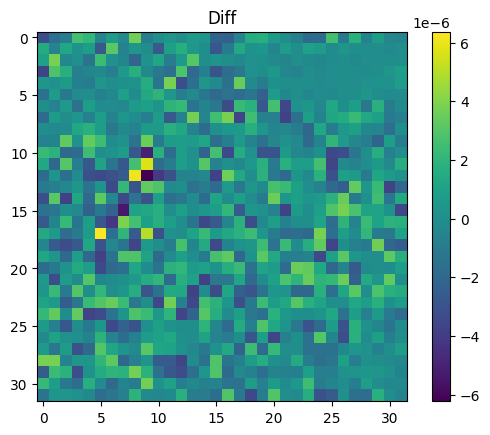

In [145]:
plt.title('Diff')
plt.imshow((original_image.ravel() - dewhitened_image.ravel()).reshape(IMAGE_SHAPE))
plt.colorbar();

# PCA Whitening

In [146]:
pca_images = IMAGES.astype('float32').copy()
assert pca_images.base is None
print(pca_images.min(), pca_images.max())

scaler = StandardScaler(with_std=False)
pca_images = pca_images.reshape(len(pca_images), -1)
pca_images = scaler.fit_transform(pca_images)

Σ0 = np.cov(pca_images, rowvar=False)
eigvals, eigvecs = np.linalg.eig(Σ0)
R, S = eigvecs, np.diag(np.sqrt(eigvals))
T = R @ S
T_inv = np.linalg.inv(T)
W = T_inv
W_inv = T
pca_images = (W @ pca_images.T).T

Σ = np.cov(pca_images, rowvar=False)

0.0 255.0


In [147]:
# W is not symmetric as in PCA

In [148]:
Σ0_hat = eigvecs @ np.diag(eigvals) @ eigvecs.T
np.allclose(Σ0, Σ0_hat)

True

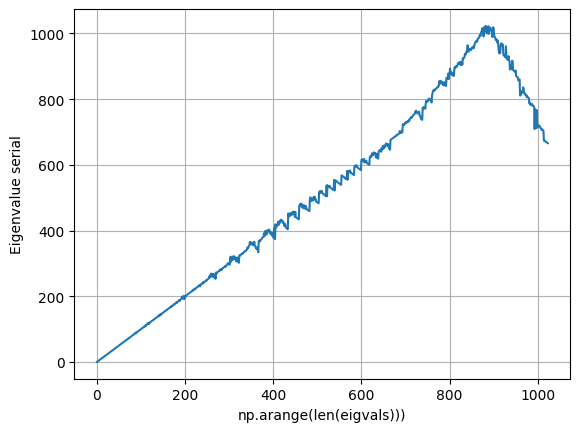

In [149]:
plt.xlabel('np.arange(len(eigvals)))')
plt.ylabel('Eigenvalue serial')
plt.grid(True)
plt.plot(np.arange(len(eigvals)), np.argsort(-eigvals))

## Whitened Σ 

In [150]:
np.round(Σ[:8,:8], 2)

array([[ 1., -0., -0., -0.,  0., -0.,  0.,  0.],
       [-0.,  1., -0., -0., -0.,  0.,  0., -0.],
       [-0., -0.,  1.,  0.,  0., -0.,  0.,  0.],
       [-0., -0.,  0.,  1., -0., -0., -0.,  0.],
       [ 0., -0.,  0., -0.,  1.,  0.,  0., -0.],
       [-0.,  0., -0., -0.,  0.,  1.,  0.,  0.],
       [ 0.,  0.,  0., -0.,  0.,  0.,  1., -0.],
       [ 0., -0.,  0.,  0., -0.,  0., -0.,  1.]])

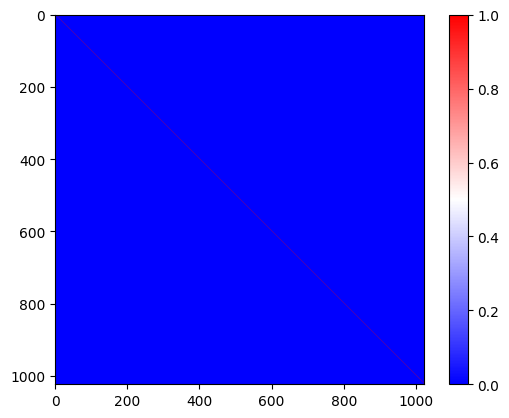

In [151]:
plt.imshow(Σ, cmap='bwr')
plt.colorbar();

## Whitening Filters

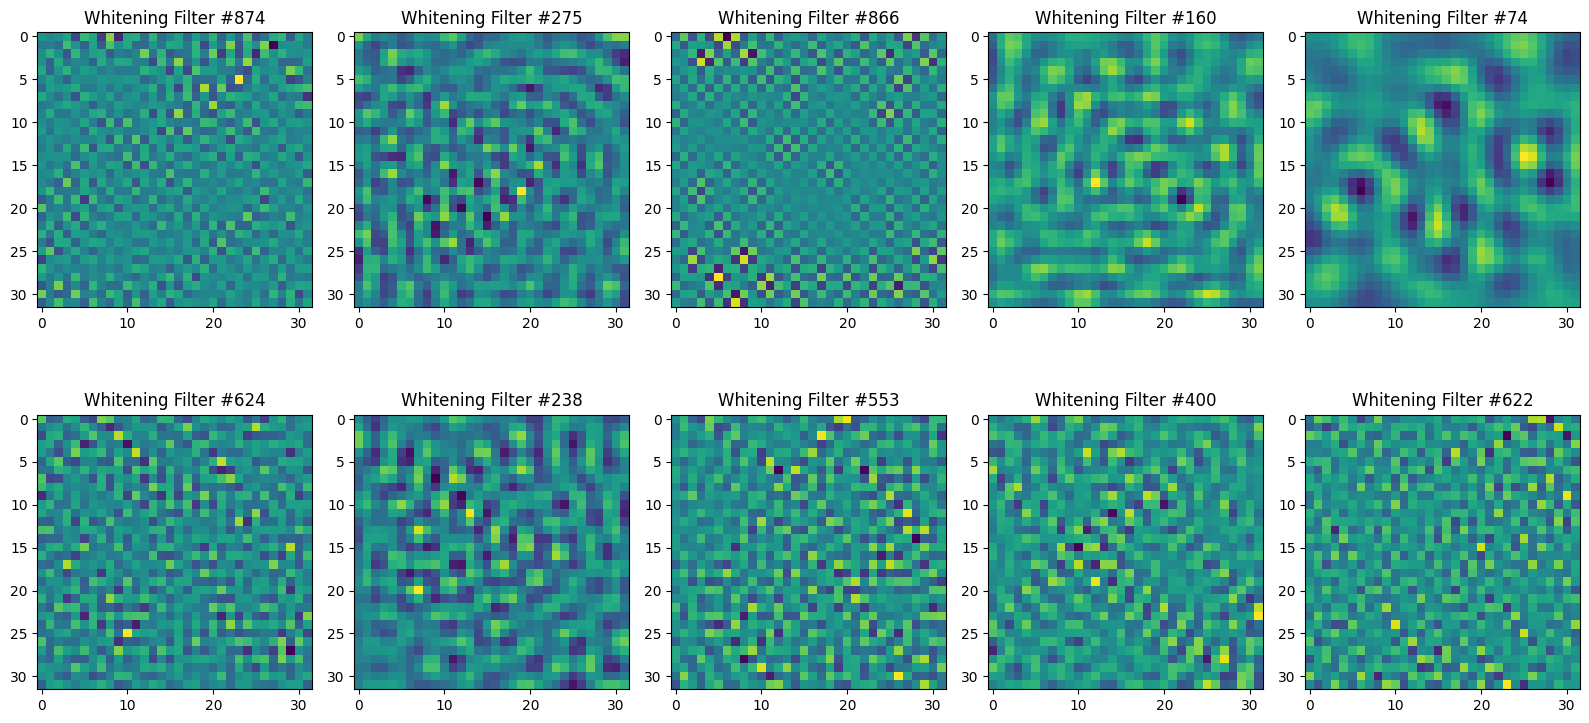

In [152]:
fig, axes = plt.subplots(len(TEST_FILTER_INDS) // 5, 5)
fig.set_figwidth(16)
fig.set_figheight(8)

for ind, ax in zip(TEST_FILTER_INDS, axes.ravel()):
    ax.set_title(f'Whitening Filter #{ind}')
    ax.imshow(W[ind].reshape(IMAGE_SHAPE));

fig.tight_layout()

Видно, что PCA вайтенинг формирует фильтры, которые имеют ярко выраженную частотную компоненту. Фильтры с низкими номерами имеют более низкую частоту, фильтры с высокими номерами - более высокую. Очень похоже на разложение Фурье!!!

Т.е. получается, что ZCA работает в пространственной зоне, а PCA - в частотной.

То же самое можно прочитать в `[KrizhevskyLearnMult]`:
> \$W\$ may also be thought of as rotating \$X\$ to the space of its principal components, dividing each principal component by the square root of the variance in that direction, and then rotating back to pixel space.

## Dewhitening Filters

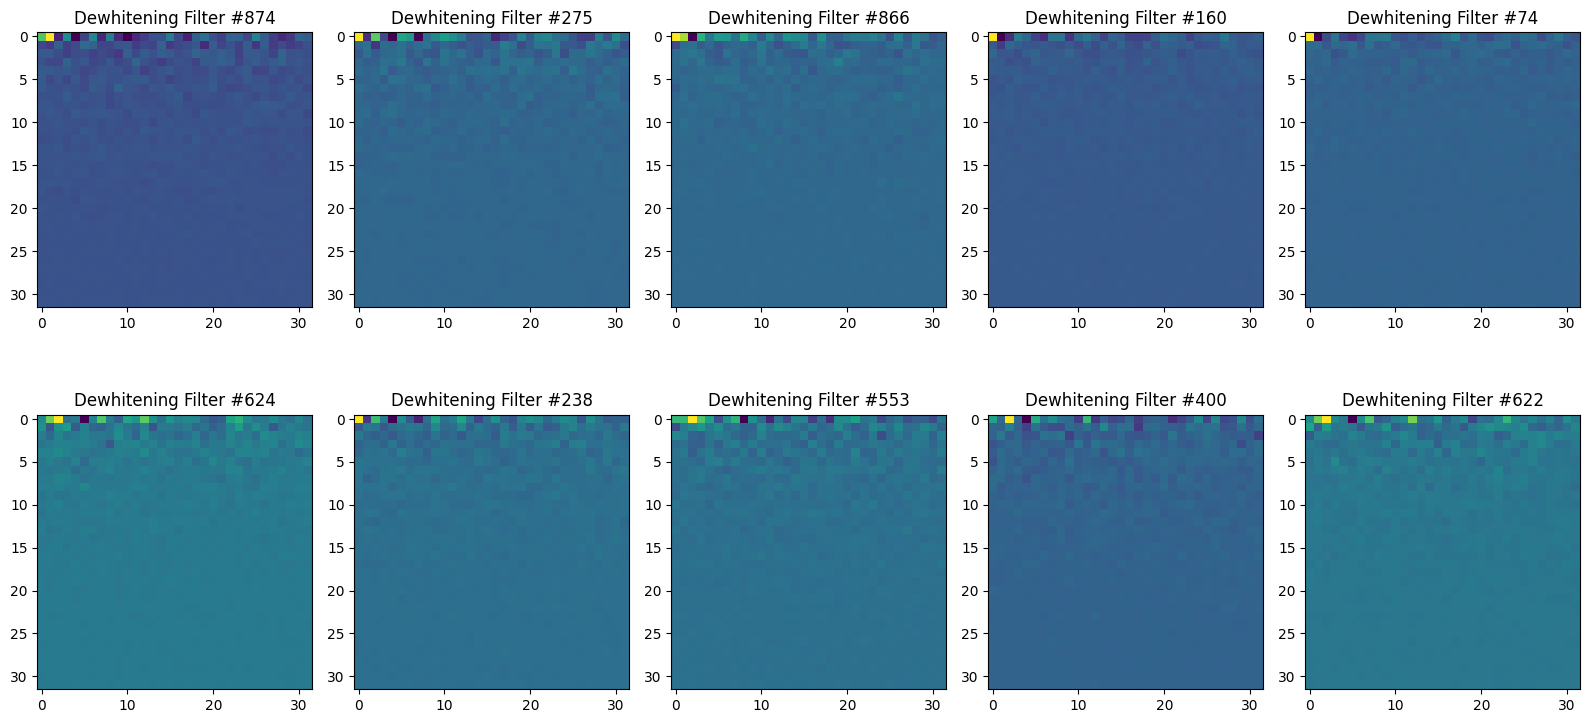

In [153]:
fig, axes = plt.subplots(len(TEST_FILTER_INDS) // 5, 5)
fig.set_figwidth(16)
fig.set_figheight(8)

for ind, ax in zip(TEST_FILTER_INDS, axes.ravel()):
    ax.set_title(f'Dewhitening Filter #{ind}')
    ax.imshow(W_inv[ind].reshape(IMAGE_SHAPE));

fig.tight_layout()

## Sample

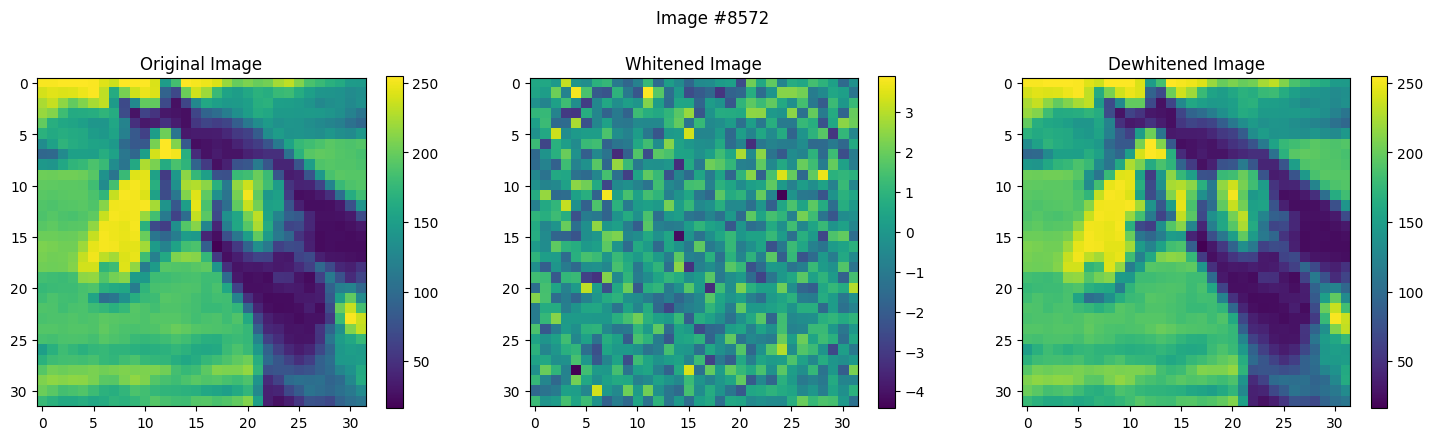

In [154]:
image_ind = TEST_IMAGE_IND # RNG.choice(len(zca_images))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figwidth(18)

fig.suptitle(f'Image #{image_ind}')

ax1.set_title('Original Image')
original_image = IMAGES[image_ind]
im = ax1.imshow(original_image.reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax1, shrink=0.9)

ax2.set_title('Whitened Image')
whitened_image = pca_images[image_ind]
im = ax2.imshow(whitened_image.reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax2, shrink=0.9);

ax3.set_title('Dewhitened Image')
dewhitened_image = W_inv @ whitened_image
dewhitened_image = scaler.inverse_transform([dewhitened_image])
im = ax3.imshow(dewhitened_image.reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax3, shrink=0.9);

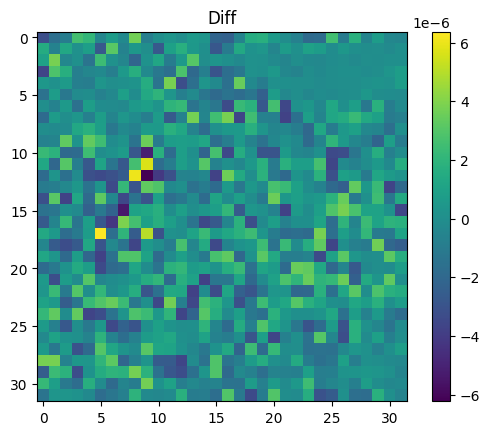

In [155]:
plt.title('Diff')
plt.imshow((original_image.ravel() - dewhitened_image.ravel()).reshape(IMAGE_SHAPE))
plt.colorbar();

# High Freqs Removal, Keep Variances

In [156]:
hfr_images = IMAGES.astype('float32').copy()
assert hfr_images.base is None
print(hfr_images.min(), hfr_images.max())

scaler = StandardScaler(with_std=False)
hfr_images = hfr_images.reshape(len(hfr_images), -1)
hfr_images = scaler.fit_transform(hfr_images)

Σ0 = np.cov(hfr_images, rowvar=False)
eigvals, eigvecs = np.linalg.eig(Σ0)
eigvals_order = np.argsort(-eigvals)
# Remove 1/3 least significant components or keep 2/3 most significant ones
wipeout_inds = eigvals_order[int(len(eigvals_order) * 0.67):]
eigvals_w = eigvals.copy()
eigvals_w[wipeout_inds] = 0

R, S = eigvecs, np.diag(np.sqrt(eigvals)) # R - rotation matrix, S - scale matrix
S_inv = np.reciprocal(S, out=np.zeros_like(S), where=(S != 0))
S_w = np.diag(np.sqrt(eigvals_w))
R_inv = R.T
W = R @ S_w @ S_inv @ R_inv 
S_w_inv = np.reciprocal(S_w, out=np.zeros_like(S_w), where=(S_w != 0))
W_inv = R @ S @ S_w_inv @ R_inv
hfr_images = (W @ hfr_images.T).T

Σ = np.cov(hfr_images, rowvar=False)

0.0 255.0


## Whitened Σ

In [157]:
np.round(Σ[:8,:8], 2)

array([[5395.95, 5205.06, 5009.84, 4857.  , 4745.15, 4641.29, 4545.23,
        4464.58],
       [5205.06, 5244.26, 5120.79, 4915.22, 4787.11, 4671.79, 4566.67,
        4482.09],
       [5009.84, 5120.79, 5209.02, 5080.12, 4899.82, 4760.65, 4649.15,
        4555.9 ],
       [4857.  , 4915.22, 5080.12, 5173.91, 5057.49, 4865.49, 4727.45,
        4621.26],
       [4745.15, 4787.11, 4899.82, 5057.49, 5147.15, 5021.23, 4825.29,
        4691.28],
       [4641.29, 4671.79, 4760.65, 4865.49, 5021.23, 5108.92, 4982.2 ,
        4798.81],
       [4545.23, 4566.67, 4649.15, 4727.45, 4825.29, 4982.2 , 5068.67,
        4956.17],
       [4464.58, 4482.09, 4555.9 , 4621.26, 4691.28, 4798.81, 4956.17,
        5060.17]])

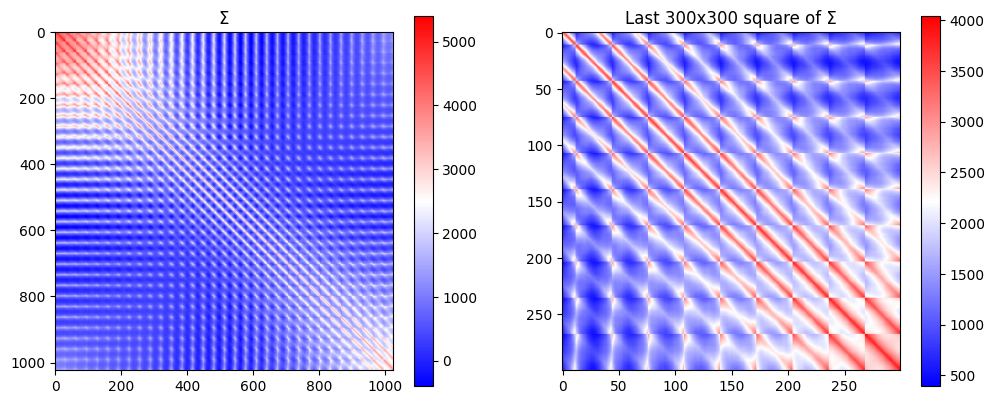

In [158]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(12)

ax1.set_title('Σ')
im = ax1.imshow(Σ, cmap='bwr')
fig.colorbar(im, ax=ax1);

ax2.set_title('Last 300x300 square of Σ')
im = ax2.imshow(Σ[-300:,-300:], cmap='bwr')
fig.colorbar(im, ax=ax2);

## Whitening Filters

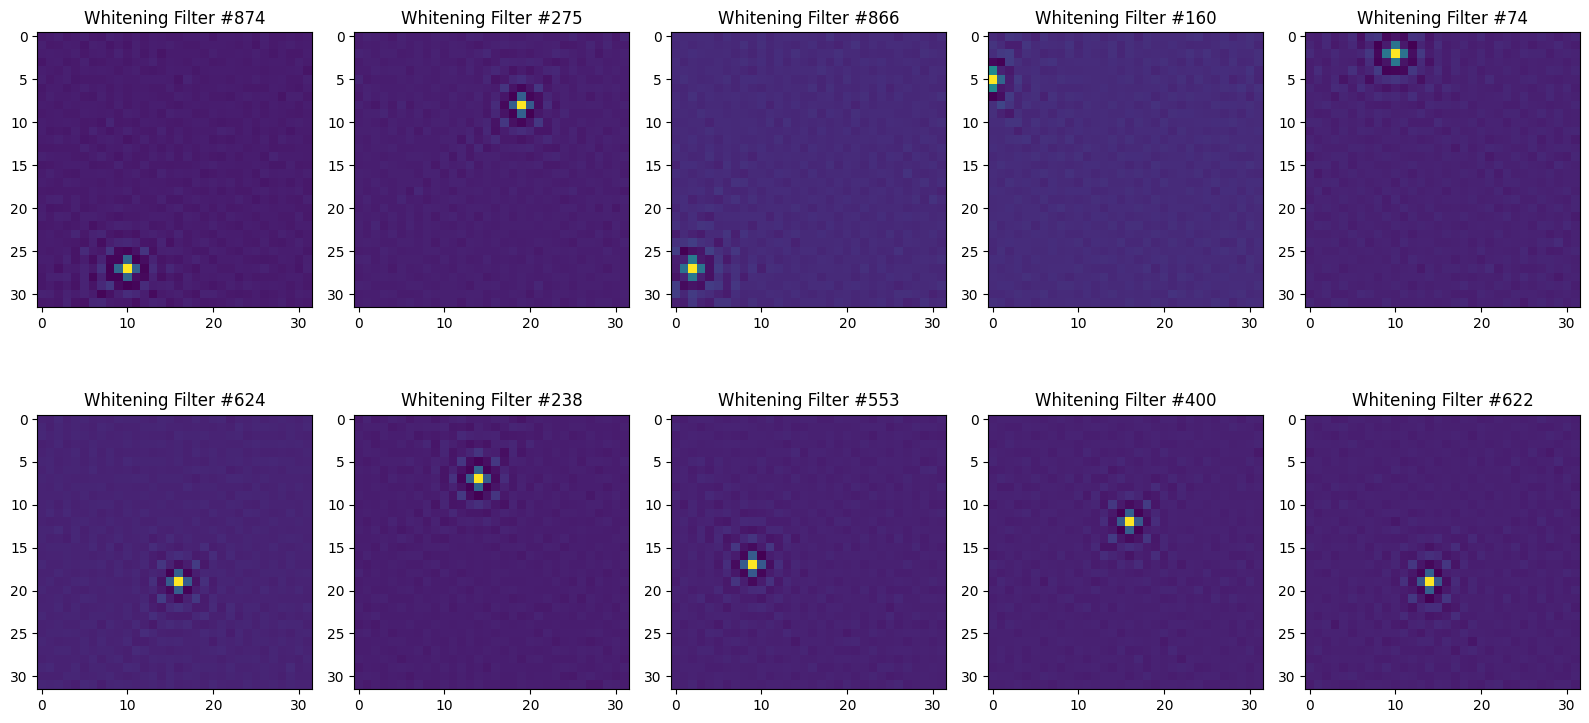

In [159]:
fig, axes = plt.subplots(len(TEST_FILTER_INDS) // 5, 5)
fig.set_figwidth(16)
fig.set_figheight(8)

for ind, ax in zip(TEST_FILTER_INDS, axes.ravel()):
    ax.set_title(f'Whitening Filter #{ind}')
    ax.imshow(W[ind].reshape(IMAGE_SHAPE));

fig.tight_layout()

## Dewhitening Filters

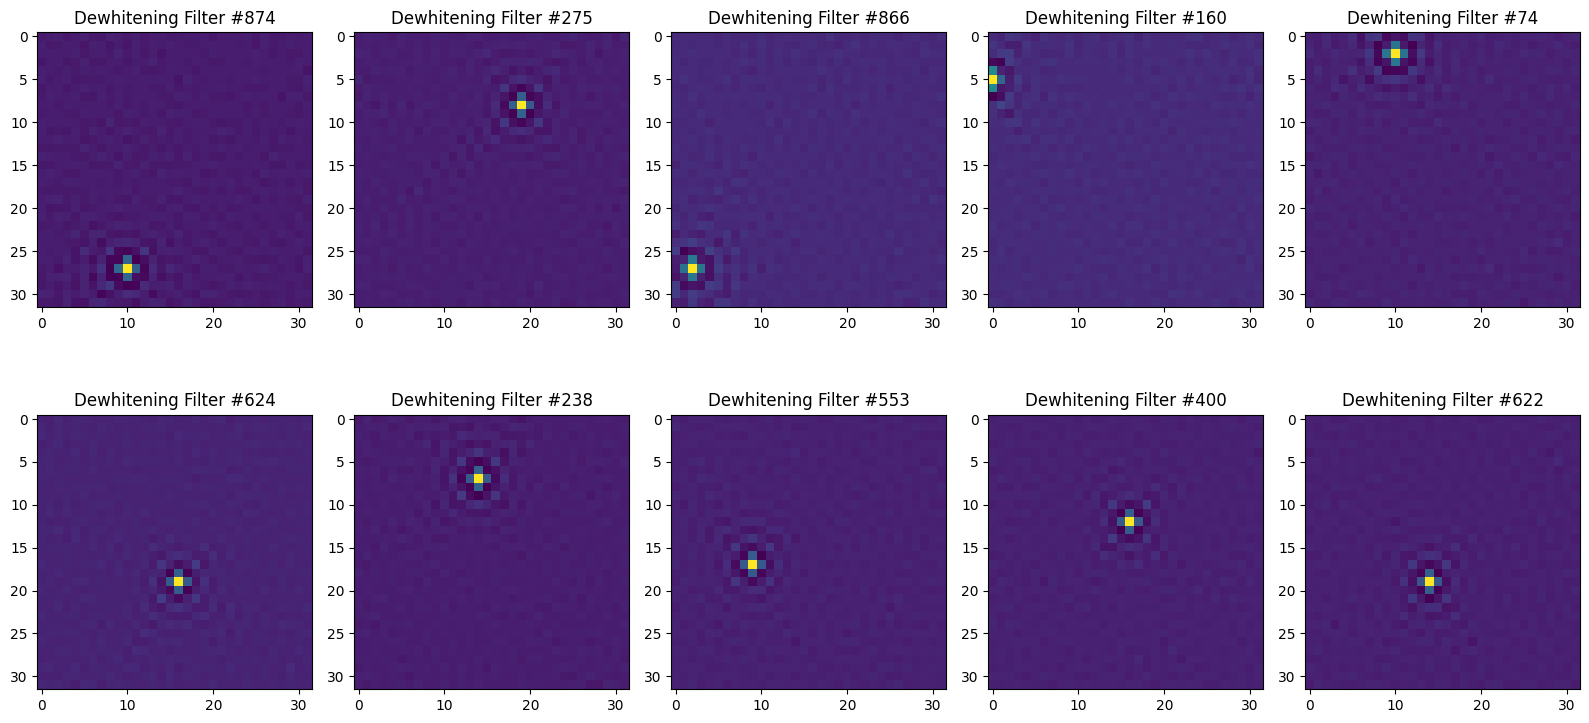

In [160]:
fig, axes = plt.subplots(len(TEST_FILTER_INDS) // 5, 5)
fig.set_figwidth(16)
fig.set_figheight(8)

for ind, ax in zip(TEST_FILTER_INDS, axes.ravel()):
    ax.set_title(f'Dewhitening Filter #{ind}')
    ax.imshow(W_inv[ind].reshape(IMAGE_SHAPE));

fig.tight_layout()

## Sample

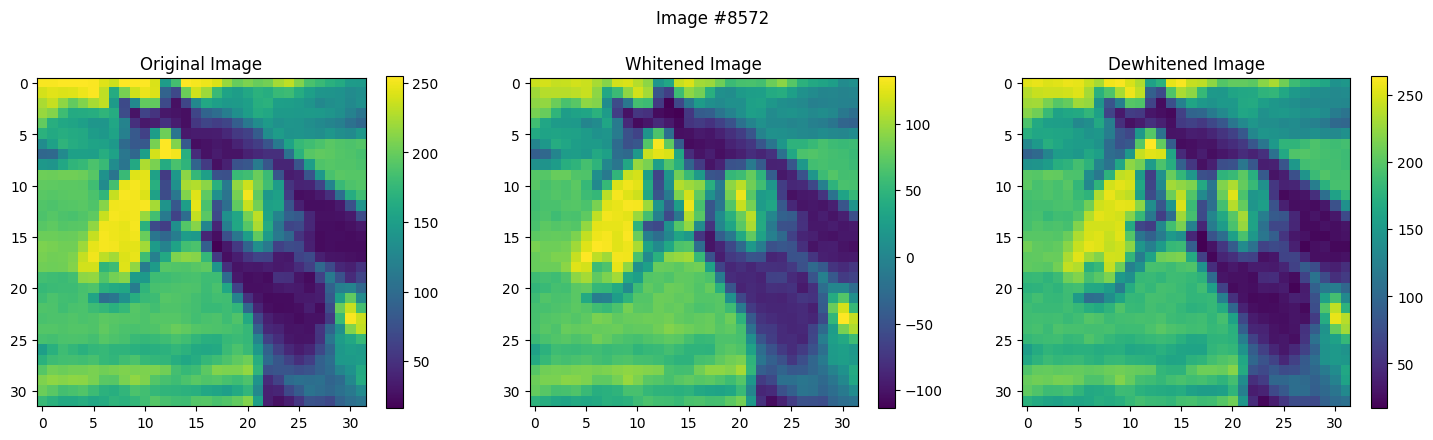

In [161]:
image_ind = TEST_IMAGE_IND # RNG.choice(len(zca_images))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figwidth(18)

fig.suptitle(f'Image #{image_ind}')

ax1.set_title('Original Image')
original_image = IMAGES[image_ind]
im = ax1.imshow(original_image.reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax1, shrink=0.9)

ax2.set_title('Whitened Image')
whitened_image = hfr_images[image_ind]
im = ax2.imshow(whitened_image.reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax2, shrink=0.9);

ax3.set_title('Dewhitened Image')
dewhitened_image = W_inv @ whitened_image
dewhitened_image = scaler.inverse_transform([dewhitened_image])
im = ax3.imshow(dewhitened_image.reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax3, shrink=0.9);

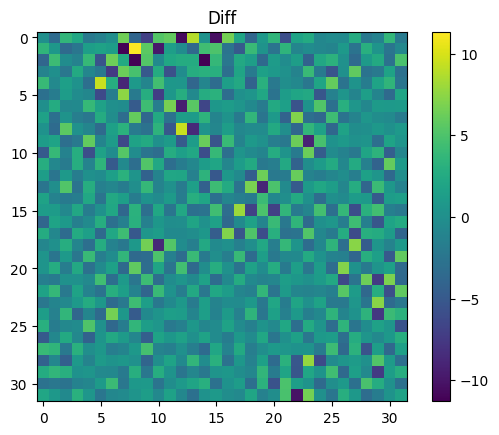

In [162]:
plt.title('Diff')
plt.imshow((original_image.ravel() - dewhitened_image.ravel()).reshape(IMAGE_SHAPE))
plt.colorbar();

# High Freqs Removal, Reset Variances

In [170]:
hfr_images = IMAGES.astype('float32').copy()
assert hfr_images.base is None
print(hfr_images.min(), hfr_images.max())

scaler = StandardScaler(with_std=False)
hfr_images = hfr_images.reshape(len(hfr_images), -1)
hfr_images = scaler.fit_transform(hfr_images)

Σ0 = np.cov(hfr_images, rowvar=False)
eigvals, eigvecs = np.linalg.eig(Σ0)
eigvals_order = np.argsort(-eigvals)
# Remove 1/3 least significant components or keep 2/3 most significant ones
wipeout_inds = eigvals_order[int(len(eigvals_order) * 0.67):]
eigvals_w = eigvals.copy()
eigvals_w[wipeout_inds] = 0

R, S = eigvecs, np.diag(np.sqrt(eigvals_w)) # R - rotation matrix, S - scale matrix
S_inv = np.reciprocal(S, out=np.zeros_like(S), where=(S != 0))
R_inv = R.T
W = R @ S_inv @ R_inv  # equiv. to: R @ np.eye(len(S_inv)) @ S_inv @ R_inv
W_inv = R @ np.diag(np.sqrt(eigvals_w)) @ R_inv
hfr_images = (W @ hfr_images.T).T

Σ = np.cov(hfr_images, rowvar=False)

0.0 255.0


## Whitened Σ

In [171]:
np.round(Σ[:8,:8], 2)

array([[ 0.79,  0.2 , -0.06,  0.02, -0.01, -0.  ,  0.01,  0.  ],
       [ 0.2 ,  0.6 ,  0.26, -0.08,  0.01,  0.01, -0.01,  0.  ],
       [-0.06,  0.26,  0.61,  0.25, -0.05, -0.01,  0.01, -0.  ],
       [ 0.02, -0.08,  0.25,  0.62,  0.24, -0.06,  0.01,  0.01],
       [-0.01,  0.01, -0.05,  0.24,  0.61,  0.25, -0.07,  0.  ],
       [-0.  ,  0.01, -0.01, -0.06,  0.25,  0.62,  0.24, -0.06],
       [ 0.01, -0.01,  0.01,  0.01, -0.07,  0.24,  0.62,  0.24],
       [ 0.  ,  0.  , -0.  ,  0.01,  0.  , -0.06,  0.24,  0.63]])

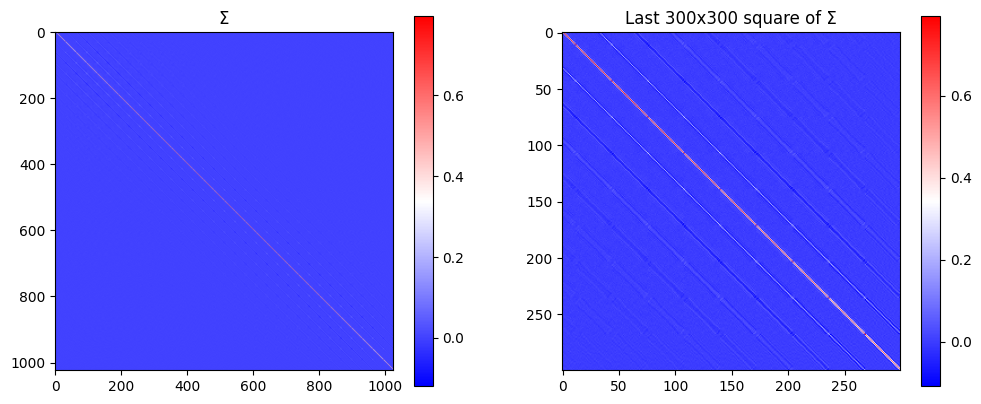

In [172]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(12)

ax1.set_title('Σ')
im = ax1.imshow(Σ, cmap='bwr')
fig.colorbar(im, ax=ax1);

ax2.set_title('Last 300x300 square of Σ')
im = ax2.imshow(Σ[-300:,-300:], cmap='bwr')
fig.colorbar(im, ax=ax2);

## Whitening Filters

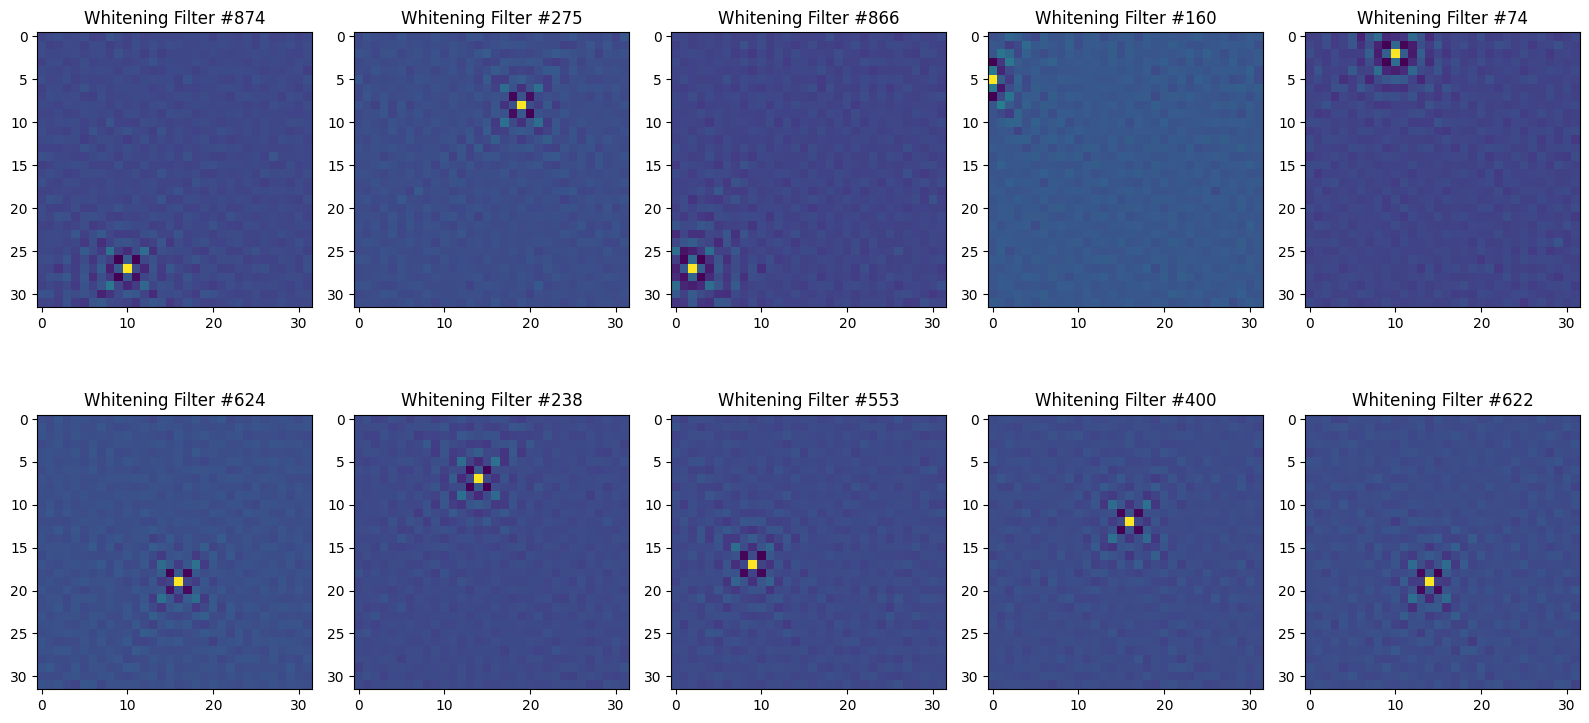

In [173]:
fig, axes = plt.subplots(len(TEST_FILTER_INDS) // 5, 5)
fig.set_figwidth(16)
fig.set_figheight(8)

for ind, ax in zip(TEST_FILTER_INDS, axes.ravel()):
    ax.set_title(f'Whitening Filter #{ind}')
    ax.imshow(W[ind].reshape(IMAGE_SHAPE));

fig.tight_layout()

## Dewhitening Filters

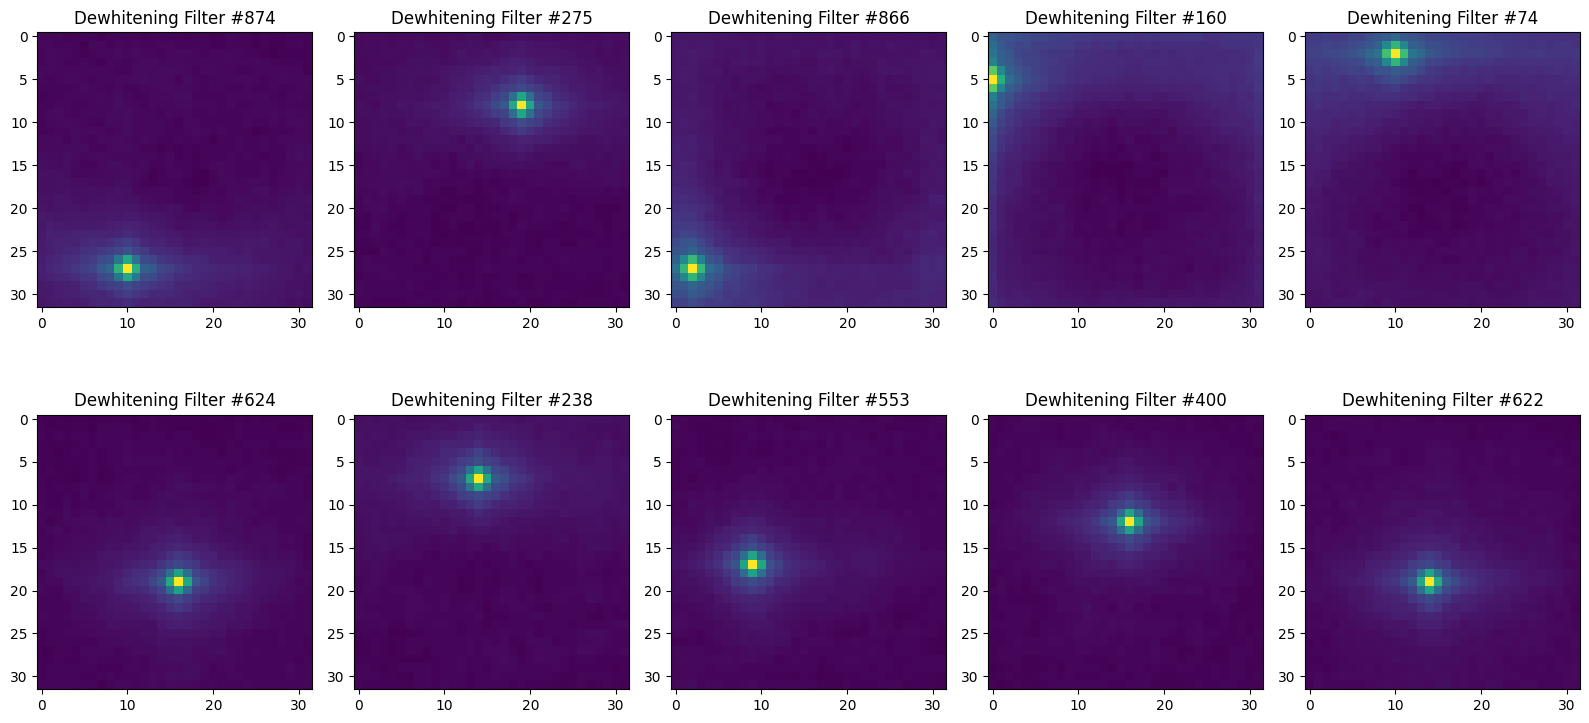

In [174]:
fig, axes = plt.subplots(len(TEST_FILTER_INDS) // 5, 5)
fig.set_figwidth(16)
fig.set_figheight(8)

for ind, ax in zip(TEST_FILTER_INDS, axes.ravel()):
    ax.set_title(f'Dewhitening Filter #{ind}')
    ax.imshow(W_inv[ind].reshape(IMAGE_SHAPE));

fig.tight_layout()

## Sample

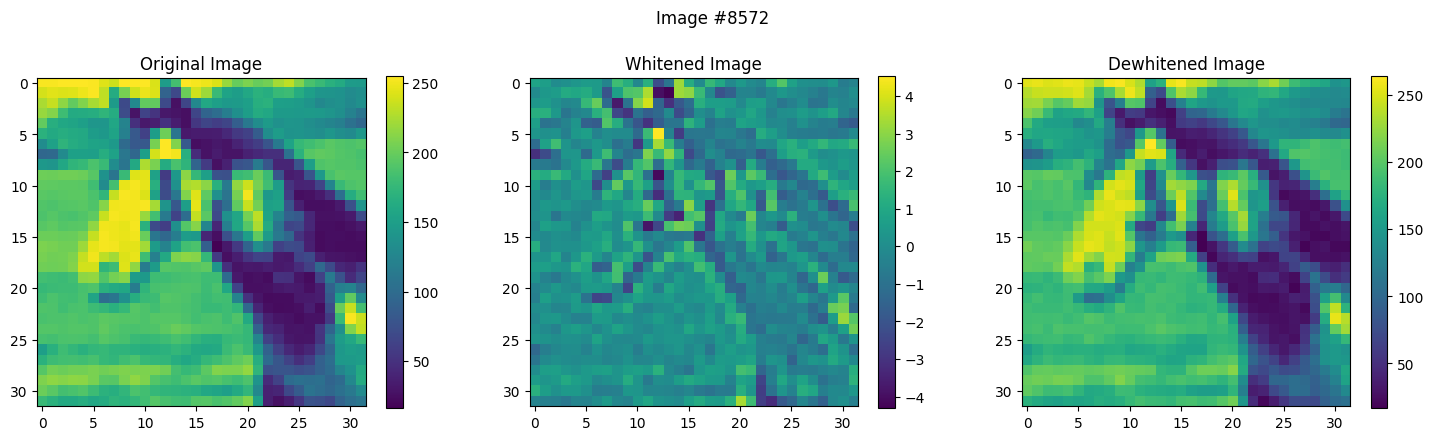

In [175]:
image_ind = TEST_IMAGE_IND # RNG.choice(len(zca_images))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figwidth(18)

fig.suptitle(f'Image #{image_ind}')

ax1.set_title('Original Image')
original_image = IMAGES[image_ind]
im = ax1.imshow(original_image.reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax1, shrink=0.9)

ax2.set_title('Whitened Image')
whitened_image = hfr_images[image_ind]
im = ax2.imshow(whitened_image.reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax2, shrink=0.9);

ax3.set_title('Dewhitened Image')
dewhitened_image = W_inv @ whitened_image
dewhitened_image = scaler.inverse_transform([dewhitened_image])
im = ax3.imshow(dewhitened_image.reshape(IMAGE_SHAPE))
fig.colorbar(im, ax=ax3, shrink=0.9);

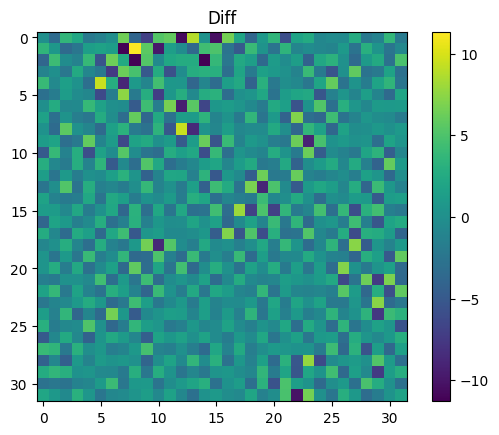

In [176]:
plt.title('Diff')
plt.imshow((original_image.ravel() - dewhitened_image.ravel()).reshape(IMAGE_SHAPE))
plt.colorbar();